# Project 3 — ARIMA vs LSTM Return Forecasting
### FIN 4333 Financial Analytics · Team Hemisphere · Company: **Target Corporation (TGT)**

**Role:** Junior Quantitative Research Analyst
**Goal:** Forecast daily stock **log returns** with a classical **ARIMA** benchmark and a
deep-learning **LSTM**, evaluate both on the *same* unseen test window using **RMSE**
(primary), **MAE** (stability), and **directional hit-rate** (secondary), and decide
whether the LSTM's added complexity is justified.

**Continuity with Project 2:** identical ticker (TGT), data source (`yfinance`,
`auto_adjust=True`), date range (2020-01-01 → 2025-01-01), and log-return definition.
This notebook reproduces that fetch and extends it to return forecasting.

> **Run order:** top-to-bottom (`Kernel → Restart & Run All`). Every output file required
> by the brief is written automatically into the project folders.


## 0. Environment & reproducibility

In [1]:
pip install pandas numpy matplotlib statsmodels scikit-learn yfinance plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [3]:
# If anything is missing, uncomment:

import os, sys, json, warnings, itertools, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# --- Resolve project root so outputs land in the required folders -----------
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
for sub in ["raw_data","processed_data","final_data","outputs","outputs/plots","references"]:
    (ROOT / sub).mkdir(parents=True, exist_ok=True)
print("Project root:", ROOT)

# Save package versions for the references/ folder (reproducibility evidence)
import importlib, platform
pkgs = ["numpy","pandas","matplotlib","statsmodels","sklearn","tensorflow","plotly","yfinance"]
lines = [f"python=={platform.python_version()}"]
for p in pkgs:
    try: lines.append(f"{p}=={importlib.import_module(p).__version__}")
    except Exception: lines.append(f"{p}==NOT_INSTALLED")
(ROOT / "references" / "package_versions.txt").write_text("\n".join(lines))
print("\n".join(lines))

Project root: C:\Users\Golam Rahat\Project 3
python==3.14.3
numpy==2.4.2
pandas==3.0.1
matplotlib==3.11.0
statsmodels==0.14.6
sklearn==1.9.0
tensorflow==NOT_INSTALLED
plotly==6.8.0
yfinance==1.4.1


## 1. Data sourcing (reuses the Project 2 workflow)
We download 5 years of TGT daily prices. With `auto_adjust=True`, the `Close` column is
already split/dividend-adjusted, so we rename it `Adjusted_Close` — matching Project 2.

In [4]:
import yfinance as yf

TICKER, START, END = "TGT", "2020-01-01", "2025-01-01"

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
# Recent yfinance returns MultiIndex columns for a single ticker — flatten it.
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

raw.to_csv(ROOT / "raw_data" / f"{TICKER}_raw_prices.csv")  # archive raw pull

df = raw[["Close"]].rename(columns={"Close": "Adjusted_Close"}).dropna()
print(f"Downloaded {len(df)} trading days for {TICKER}  ({df.index.min().date()} → {df.index.max().date()})")
df.head()

Downloaded 1258 trading days for TGT  (2020-01-02 → 2024-12-31)


Price,Adjusted_Close
Date,
2020-01-02,105.475006
2020-01-03,104.378983
2020-01-06,103.391747
2020-01-07,103.575836
2020-01-08,103.241158


### 1.1 Daily log returns
$$r_t = \ln\!\left(\dfrac{P_t}{P_{t-1}}\right)$$
Log returns are time-additive and closer to stationary than raw prices — the right target
for ARIMA/LSTM.

In [5]:
df["log_return"] = np.log(df["Adjusted_Close"] / df["Adjusted_Close"].shift(1))
df = df.dropna().copy()
df.to_csv(ROOT / "processed_data" / f"{TICKER}_prices_logret.csv")
print("Mean daily return: %.5f | Daily vol: %.5f | N = %d" %
      (df['log_return'].mean(), df['log_return'].std(), len(df)))
df[["Adjusted_Close","log_return"]].describe()

Mean daily return: 0.00015 | Daily vol: 0.02305 | N = 1257


Price,Adjusted_Close,log_return
count,1257.000000,1257.000000
mean,145.786093,0.000148
std,35.238000,0.023054
min,76.601028,-0.286753
25%,123.844872,-0.009164
50%,140.409637,0.000223
75%,161.279999,0.010812
max,230.500504,0.163430


## 2. Chronological train / validation / test split (no leakage)
Time series **must** be split by time, never shuffled. We use **70% train · 15% validation
· 15% test**. Validation is used for model selection; the **test window is touched only once**,
for the final head-to-head.

In [6]:
N = len(df)
n_train = int(N * 0.70)
n_val   = int(N * 0.15)
n_test  = N - n_train - n_val

labels = (["train"]*n_train) + (["validation"]*n_val) + (["test"]*n_test)
df["split"] = labels

r = df["log_return"].to_numpy()
train_r = r[:n_train]
val_r   = r[n_train:n_train+n_val]
test_r  = r[n_train+n_val:]

def span(name, s, e):
    return f"{name:<11} {df.index[s].date()} → {df.index[e-1].date()}  ({e-s} days)"
print(span("train", 0, n_train))
print(span("validation", n_train, n_train+n_val))
print(span("test", n_train+n_val, N))

# --- FORECAST-READY DATASET (required deliverable) --------------------------
ready = df[["Adjusted_Close","log_return","split"]].copy()
ready.index.name = "date"
ready.to_csv(ROOT / "final_data" / f"{TICKER}_forecast_ready.csv")
print("\nSaved → final_data/%s_forecast_ready.csv" % TICKER)

train       2020-01-03 → 2023-06-30  (879 days)
validation  2023-07-03 → 2024-04-01  (188 days)
test        2024-04-02 → 2024-12-31  (190 days)

Saved → final_data/TGT_forecast_ready.csv


### 2.1 Visual check — prices (non-stationary) vs returns (stationary candidate)

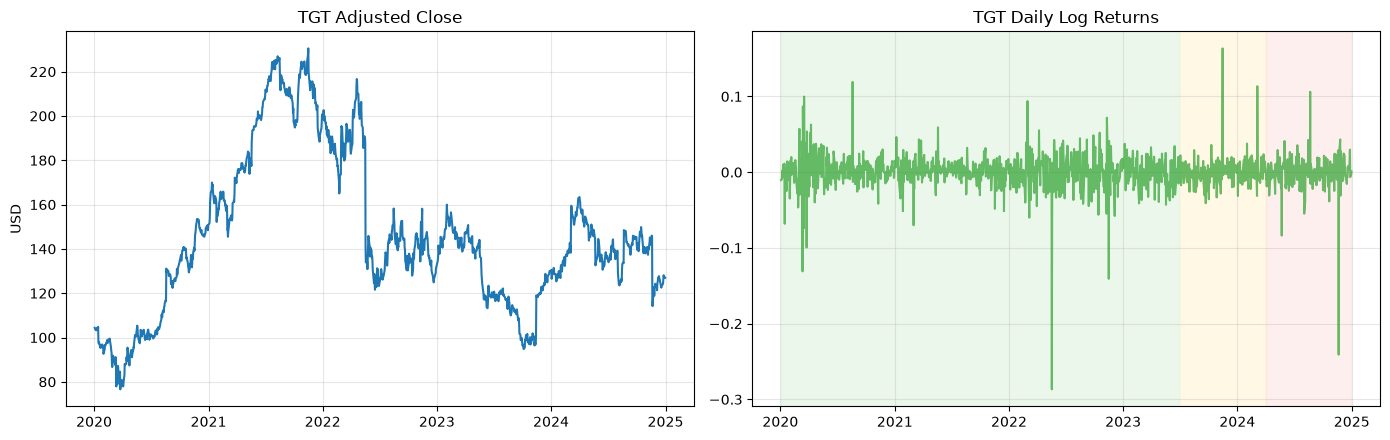

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14,4.5))
ax[0].plot(df.index, df["Adjusted_Close"], color="#1f77b4")
ax[0].set_title(f"{TICKER} Adjusted Close"); ax[0].set_ylabel("USD"); ax[0].grid(alpha=.3)
ax[1].plot(df.index, df["log_return"], color="#2ca02c", alpha=.7)
ax[1].set_title(f"{TICKER} Daily Log Returns"); ax[1].grid(alpha=.3)
for x,(s,e,c) in zip([ax[1]]*3, [(0,n_train,"#d9f0d9"),(n_train,n_train+n_val,"#fff2cc"),(n_train+n_val,N,"#fde0dc")]):
    x.axvspan(df.index[s], df.index[e-1], color=c, alpha=.5, zorder=0)
plt.tight_layout()
plt.savefig(ROOT/"outputs"/"plots"/"01_price_vs_returns.png", dpi=130, bbox_inches="tight")
plt.show()

## 3. ADF stationarity test
**Null hypothesis $H_0$:** the series has a unit root (non-stationary). A p-value below 0.05
lets us reject $H_0$ and treat the series as stationary — meaning ARIMA needs **no differencing
($d=0$)** on returns.

In [8]:
from statsmodels.tsa.stattools import adfuller
adf_stat, adf_p, *_ = adfuller(df["log_return"])
print(f"ADF statistic: {adf_stat:.4f}")
print(f"p-value:       {adf_p:.3e}")
if adf_p < 0.05:
    print("\n→ Reject H0: the daily log-return series is STATIONARY.")
    print("  In plain terms, returns fluctuate around a stable mean with no growing trend,")
    print("  so we model them directly with d = 0 (no differencing needed).")
else:
    print("\n→ Fail to reject H0: series may be non-stationary; differencing may be required.")

ADF statistic: -36.3938
p-value:       0.000e+00

→ Reject H0: the daily log-return series is STATIONARY.
  In plain terms, returns fluctuate around a stable mean with no growing trend,
  so we model them directly with d = 0 (no differencing needed).


## 4. ARIMA benchmark
**Selection:** grid-search $(p,d,q)$ by **AIC** on the training set, then confirm the best
candidates by **walk-forward validation RMSE** (the brief's "use the validation period for
model selection"). **Final test:** refit the chosen order on *train+validation* and produce
**walk-forward one-step-ahead** forecasts across the test window — true out-of-sample, no leakage.

In [9]:
from statsmodels.tsa.arima.model import ARIMA

def walk_forward(order, history, future):
    # One-step-ahead rolling forecast; returns (preds, rmse).
    # Appends each realized value (no refit) — standard, leakage-free.
    res = ARIMA(history, order=order).fit()
    preds = []
    for actual in future:
        preds.append(float(np.asarray(res.forecast(1))[0]))
        res = res.append([actual], refit=False)
    preds = np.array(preds)
    rmse = float(np.sqrt(np.mean((preds - future)**2)))
    return preds, rmse

# --- AIC grid search on TRAIN ----------------------------------------------
print(f"{'ARIMA(p,d,q)':<16}{'AIC':>12}")
print("-"*28)
scored = []
for p, d, q in itertools.product(range(0,4), [0], range(0,4)):
    if p == 0 and q == 0:
        continue
    try:
        aic = ARIMA(train_r, order=(p,d,q)).fit().aic
        scored.append(((p,d,q), aic))
        print(f"ARIMA{str((p,d,q)):<11}{aic:>12.3f}")
    except Exception:
        pass
scored.sort(key=lambda x: x[1])
top5 = scored[:5]
print("\nTop-5 by AIC:", [o for o,_ in top5])

ARIMA(p,d,q)             AIC
----------------------------
ARIMA(0, 0, 1)     -4128.142
ARIMA(0, 0, 2)     -4126.895
ARIMA(0, 0, 3)     -4124.920
ARIMA(1, 0, 0)     -4128.258
ARIMA(1, 0, 1)     -4126.374
ARIMA(1, 0, 2)     -4124.424
ARIMA(1, 0, 3)     -4129.817
ARIMA(2, 0, 0)     -4126.827
ARIMA(2, 0, 1)     -4124.705


C:\Users\Golam Rahat\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 0, 2)     -4137.808


C:\Users\Golam Rahat\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 0, 3)     -4133.224
ARIMA(3, 0, 0)     -4124.868
ARIMA(3, 0, 1)     -4122.852
ARIMA(3, 0, 2)     -4120.884
ARIMA(3, 0, 3)     -4122.922

Top-5 by AIC: [(2, 0, 2), (2, 0, 3), (1, 0, 3), (1, 0, 0), (0, 0, 1)]


C:\Users\Golam Rahat\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [10]:
# --- Confirm top candidates on VALIDATION (walk-forward RMSE) ---------------
best_order, best_val_rmse = None, np.inf
for order, aic in top5:
    try:
        _, vr = walk_forward(order, train_r, val_r)
        print(f"ARIMA{order}  AIC={aic:.2f}  val_RMSE={vr:.6f}")
        if vr < best_val_rmse:
            best_order, best_val_rmse = order, vr
    except Exception as e:
        print(f"ARIMA{order} skipped ({e})")

ARIMA_ORDER = best_order
arima_aic = ARIMA(train_r, order=ARIMA_ORDER).fit().aic
print(f"\n>>> Selected ARIMA order: {ARIMA_ORDER} | train AIC = {arima_aic:.3f} | val RMSE = {best_val_rmse:.6f}")

C:\Users\Golam Rahat\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 0, 2)  AIC=-4137.81  val_RMSE=0.020436


C:\Users\Golam Rahat\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(2, 0, 3)  AIC=-4133.22  val_RMSE=0.020484
ARIMA(1, 0, 3)  AIC=-4129.82  val_RMSE=0.020381
ARIMA(1, 0, 0)  AIC=-4128.26  val_RMSE=0.020408
ARIMA(0, 0, 1)  AIC=-4128.14  val_RMSE=0.020403

>>> Selected ARIMA order: (1, 0, 3) | train AIC = -4129.817 | val RMSE = 0.020381


In [11]:
# --- FINAL TEST: refit on train+val, walk forward across the test window ----
trainval_r = r[:n_train+n_val]
arima_preds, arima_rmse = walk_forward(ARIMA_ORDER, trainval_r, test_r)
arima_mae = float(np.mean(np.abs(arima_preds - test_r)))
arima_dir = float(np.mean(np.sign(arima_preds) == np.sign(test_r)) * 100)
print(f"ARIMA{ARIMA_ORDER} — TEST set")
print(f"  RMSE = {arima_rmse:.6f}")
print(f"  MAE  = {arima_mae:.6f}")
print(f"  Directional accuracy = {arima_dir:.2f}%")

C:\Users\Golam Rahat\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1, 0, 3) — TEST set
  RMSE = 0.025711
  MAE  = 0.014454
  Directional accuracy = 54.74%


## 5. LSTM model
**Design (per brief):** sliding window of the previous **10** daily returns → predict the next
return; a single **LSTM(50)** layer + **Dense(1)** output. **Scaling is fit on training data
only** (no leakage), then applied to all splits. We monitor validation loss with
**EarlyStopping**. Crucially, the LSTM is scored on the **same test dates** as ARIMA so the
comparison is apples-to-apples.

In [12]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)
WINDOW = 10

# Scale on TRAIN ONLY, then transform the whole series
scaler = StandardScaler().fit(train_r.reshape(-1,1))
r_scaled = scaler.transform(r.reshape(-1,1)).flatten()

def make_windows(series, start, end, win=WINDOW):
    # Predict target at t from the WIN returns before t, for t in [start,end).
    X, y = [], []
    for t in range(max(start, win), end):
        X.append(series[t-win:t]); y.append(series[t])
    return np.array(X)[..., None], np.array(y)

Xtr, ytr = make_windows(r_scaled, WINDOW, n_train)
Xv,  yv  = make_windows(r_scaled, n_train, n_train+n_val)
Xte, yte = make_windows(r_scaled, n_train+n_val, N)
print("Window tensors:", Xtr.shape, Xv.shape, Xte.shape)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
model = Sequential([Input((WINDOW,1)), LSTM(50), Dense(1)])
model.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
history = model.fit(Xtr, ytr, validation_data=(Xv, yv),
                    epochs=60, batch_size=32, callbacks=[es], verbose=0)
print(f"Trained {len(history.history['loss'])} epochs "
      f"(best val_loss = {min(history.history['val_loss']):.5f})")

# Training curve
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("LSTM learning curve"); plt.xlabel("epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.grid(alpha=.3)
plt.savefig(ROOT/"outputs"/"plots"/"02_lstm_learning_curve.png", dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
# Predict on test, invert scaling, score on the SAME dates as ARIMA
pred_scaled = model.predict(Xte, verbose=0).flatten()
lstm_preds  = scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
lstm_actual = scaler.inverse_transform(yte.reshape(-1,1)).flatten()

# Alignment guarantee: identical test targets for both models
assert len(lstm_actual) == len(test_r) and np.allclose(lstm_actual, test_r), "test misalignment!"

lstm_rmse = float(np.sqrt(np.mean((lstm_preds - test_r)**2)))
lstm_mae  = float(np.mean(np.abs(lstm_preds - test_r)))
lstm_dir  = float(np.mean(np.sign(lstm_preds) == np.sign(test_r)) * 100)
print("LSTM — TEST set")
print(f"  RMSE = {lstm_rmse:.6f}")
print(f"  MAE  = {lstm_mae:.6f}")
print(f"  Directional accuracy = {lstm_dir:.2f}%")
print("\nAlignment check passed: both models scored on identical test dates.")

## 6. Model comparison & decision rule
**Primary:** test RMSE (penalizes large errors). **Stability check:** MAE.
**Secondary business metric:** directional accuracy (sign correctness ≠ profit after costs).
**Rule:** if the LSTM's RMSE edge is tiny or unstable, prefer **ARIMA** — simpler, faster,
explainable.

In [ ]:
comparison = pd.DataFrame({
    "Model": [f"ARIMA{ARIMA_ORDER}", "LSTM (10→50→1)"],
    "Forecast_target": ["Daily log return", "Daily log return"],
    "Test_MAE":  [round(arima_mae,6),  round(lstm_mae,6)],
    "Test_RMSE": [round(arima_rmse,6), round(lstm_rmse,6)],
    "Directional_accuracy_%": [round(arima_dir,2), round(lstm_dir,2)],
})
comparison.to_csv(ROOT/"outputs"/"model_comparison_table.csv", index=False)
print("Saved → outputs/model_comparison_table.csv\n")
comparison

In [ ]:
# --- Apply the decision rule -----------------------------------------------
rel_gain = (arima_rmse - lstm_rmse) / arima_rmse * 100   # % RMSE improvement of LSTM
MATERIAL = 3.0  # treat <3% RMSE improvement as "tiny"

if lstm_rmse < arima_rmse and rel_gain >= MATERIAL:
    SELECTED = f"LSTM (10→50→1)"
    reason = (f"LSTM lowers test RMSE by {rel_gain:.1f}% (≥{MATERIAL}% threshold), "
              "a materially better fit that justifies the added complexity.")
else:
    SELECTED = f"ARIMA{ARIMA_ORDER}"
    if lstm_rmse < arima_rmse:
        reason = (f"LSTM's RMSE edge is only {rel_gain:.1f}% (< {MATERIAL}% threshold) — "
                  "too small to justify its cost, training time, and opacity.")
    else:
        reason = (f"ARIMA matches or beats LSTM on RMSE while being simpler, faster, "
                  "and far easier to explain to an investment committee.")
print(f"RMSE improvement of LSTM over ARIMA: {rel_gain:.2f}%")
print(f"\n>>> RECOMMENDED MODEL: {SELECTED}")
print("Rationale:", reason)

### 6.1 Actual vs forecast on the test window

In [ ]:
test_dates = df.index[n_train+n_val:]
plt.figure(figsize=(13,5))
plt.plot(test_dates, test_r, label="Actual", color="black", lw=1)
plt.plot(test_dates, arima_preds, label=f"ARIMA{ARIMA_ORDER}", color="#1f77b4", alpha=.8)
plt.plot(test_dates, lstm_preds, label="LSTM", color="#d62728", alpha=.8)
plt.title(f"{TICKER}: Actual vs Forecast Daily Log Returns (Test)")
plt.ylabel("log return"); plt.legend(); plt.grid(alpha=.3)
plt.savefig(ROOT/"outputs"/"plots"/"03_actual_vs_forecast_test.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Next-30-trading-day return outlook
We refit the chosen ARIMA order on the **full** series for its 30-step forecast, and roll the
LSTM forward recursively. Both are saved; the **selected** model drives the headline outlook.
Return forecasts are noisy — treat them as directional context, not guaranteed signals.

In [ ]:
# ARIMA 30-day (refit on full series)
arima_full = ARIMA(r, order=ARIMA_ORDER).fit()
arima_30 = np.asarray(arima_full.forecast(30), dtype=float)

# LSTM 30-day (recursive on scaled series)
seq = list(r_scaled[-WINDOW:])
lstm_30_scaled = []
for _ in range(30):
    x = np.array(seq[-WINDOW:])[None,:,None]
    nxt = float(model.predict(x, verbose=0).flatten()[0])
    lstm_30_scaled.append(nxt); seq.append(nxt)
lstm_30 = scaler.inverse_transform(np.array(lstm_30_scaled).reshape(-1,1)).flatten()

future_dates = pd.bdate_range(df.index[-1] + pd.Timedelta(days=1), periods=30)
forecast_30 = pd.DataFrame({
    "date": future_dates,
    "horizon_day": range(1,31),
    "arima_log_return": np.round(arima_30,6),
    "lstm_log_return":  np.round(lstm_30,6),
    "selected_model": SELECTED,
})
forecast_30["selected_log_return"] = (
    forecast_30["arima_log_return"] if SELECTED.startswith("ARIMA")
    else forecast_30["lstm_log_return"])
forecast_30["cumulative_selected_return"] = forecast_30["selected_log_return"].cumsum().round(6)
forecast_30.to_csv(ROOT/"outputs"/"30_day_return_forecast.csv", index=False)
print("Saved → outputs/30_day_return_forecast.csv")
cum = forecast_30["cumulative_selected_return"].iloc[-1]
print(f"\nSelected model ({SELECTED}) 30-day cumulative log return: {cum:+.4f}  "
      f"(≈ {np.exp(cum)-1:+.2%} price move)")
forecast_30.head()

## 8. Interactive Plotly dashboard (executive deliverable)
A web-ready HTML dashboard: actual-vs-forecast on the test window plus the 30-day outlook.
Saved to `outputs/plots/` for embedding in the portfolio.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

dash = make_subplots(rows=2, cols=1, vertical_spacing=0.12,
    subplot_titles=(f"{TICKER}: Actual vs Forecast (Test)", "Next 30 Trading Days — Forecast"))

dash.add_trace(go.Scatter(x=test_dates, y=test_r, name="Actual",
               line=dict(color="black", width=1)), 1, 1)
dash.add_trace(go.Scatter(x=test_dates, y=arima_preds, name=f"ARIMA{ARIMA_ORDER}",
               line=dict(color="#1f77b4")), 1, 1)
dash.add_trace(go.Scatter(x=test_dates, y=lstm_preds, name="LSTM",
               line=dict(color="#d62728")), 1, 1)

dash.add_trace(go.Scatter(x=future_dates, y=arima_30, name=f"ARIMA{ARIMA_ORDER} 30d",
               line=dict(color="#1f77b4", dash="dash")), 2, 1)
dash.add_trace(go.Scatter(x=future_dates, y=lstm_30, name="LSTM 30d",
               line=dict(color="#d62728", dash="dash")), 2, 1)
dash.add_hline(y=0, line_dash="dot", line_color="gray", row=2, col=1)

dash.update_layout(height=720, template="plotly_white",
    title_text=f"TGT Return Forecasting Dashboard — Recommended: {SELECTED}",
    legend=dict(orientation="h", y=-0.08))
dash.update_yaxes(title_text="log return")
out_html = ROOT/"outputs"/"plots"/"interactive_forecast_dashboard.html"
dash.write_html(str(out_html))
print("Saved →", out_html.relative_to(ROOT))
dash.show()

## 9. Run summary — files written

In [ ]:
produced = {
    "Forecast-ready dataset": f"final_data/{TICKER}_forecast_ready.csv",
    "Comparison table":       "outputs/model_comparison_table.csv",
    "30-day forecast":        "outputs/30_day_return_forecast.csv",
    "Plots (PNG)":            "outputs/plots/01..03_*.png",
    "Interactive dashboard":  "outputs/plots/interactive_forecast_dashboard.html",
    "Package versions":       "references/package_versions.txt",
}
for k,v in produced.items():
    print(f"  ✓ {k:<24} → {v}")

print("\n================ RESULTS SNAPSHOT ================")
print(comparison.to_string(index=False))
print(f"\nRecommended model: {SELECTED}")
print(f"Rationale: {reason}")
print("\nCaveat: daily returns are near-random; directional accuracy ~50% is normal.")
print("Forecasts are uncertain and are NOT standalone trading signals.")

---
### Interpretation notes (for the memo & viva)
- **Why ARIMA usually wins here.** Daily equity log returns are close to white noise, so a
  parsimonious linear model captures essentially all the (weak) linear structure. An LSTM has
  far more parameters to fit roughly the same near-zero predictable signal, so it tends to match
  — not beat — ARIMA out-of-sample, while costing more time and transparency.
- **Reading RMSE vs MAE.** RMSE ≥ MAE always; a large gap flags a few big misses (e.g. earnings
  gaps). We lead with RMSE because large errors are the expensive ones for a risk desk.
- **Directional accuracy ≈ 50%** is expected and does **not** imply a profitable strategy once
  transaction costs and slippage are included.
- **30-day outlook** should be communicated as a low-confidence central tendency with wide
  uncertainty, never as a guaranteed path.
